In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:

ROOT_DIR = '/content/gdrive/MyDrive/ComputerVisionDeveloper'

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.3 MB/s eta 0:00:00


In [ ]:
!unzip -o -q "/content/gdrive/MyDrive/ComputerVisionDeveloper/TrainYolov8CustomDataset.zip" -d "/content/dataset_lp"

In [ ]:
import yaml

# Cấu hình mới trỏ vào nơi vừa giải nén
data_config = {
    'path': '/content/dataset_lp', # Thêm chữ _lp vào cho đúng với lệnh unzip ở trên
    'train': 'train/images',
    'val': 'valid/images',
    'nc': 1,
    'names': ['license-plate']
}

# Ghi đè vào file trên Drive của ông chủ
config_path = '/content/gdrive/MyDrive/ComputerVisionDeveloper/google_colab_config.yaml'
with open(config_path, 'w') as f:
    yaml.dump(data_config, f)

print("✅ Đã sửa file YAML! Giờ đường dẫn cực kỳ sạch sẽ.")

✅ Đã sửa file YAML! Giờ đường dẫn cực kỳ sạch sẽ.


In [ ]:
import os
import yaml
from ultralytics import YOLO
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/gdrive')

# 2. Định nghĩa các đường dẫn
ZIP_PATH = "/content/gdrive/MyDrive/ComputerVisionDeveloper/TrainYolov8CustomDataset.zip"
EXTRACT_PATH = "/content/dataset_lp"
CONFIG_PATH = "/content/gdrive/MyDrive/ComputerVisionDeveloper/google_colab_config.yaml"
PROJECT_DIR = "/content/gdrive/MyDrive/ComputerVisionDeveloper/runs" # Lưu trực tiếp vào Drive

# 3. Giải nén Dataset (chỉ giải nén nếu chưa có để tiết kiệm thời gian)
if not os.path.exists(EXTRACT_PATH):
    print("📦 Đang giải nén dataset...")
    !unzip -q "{ZIP_PATH}" -d "{EXTRACT_PATH}"
    print("✅ Giải nén xong!")

# 4. Tự động cập nhật file YAML để khớp với đường dẫn Colab
data_config = {
    'path': EXTRACT_PATH,
    'train': 'train/images',
    'val': 'valid/images',
    'nc': 1,
    'names': ['license-plate']
}

with open(CONFIG_PATH, 'w') as f:
    yaml.dump(data_config, f)
print(f"📝 Đã cập nhật cấu hình tại: {CONFIG_PATH}")

# 5. Khởi tạo Model và Huấn luyện
# Kiểm tra xem có file 'last.pt' để resume không
last_model_path = os.path.join(PROJECT_DIR, 'license_plate_train/weights/last.pt')

if os.path.exists(last_model_path):
    print("🔄 Tìm thấy checkpoint cũ, đang tiếp tục huấn luyện (Resume)...")
    model = YOLO(last_model_path)
    results = model.train(resume=True)
else:
    print("🚀 Bắt đầu huấn luyện mới...")
    model = YOLO("yolov8s.pt")
    results = model.train(
        data=CONFIG_PATH,
        epochs=50,
        imgsz=640,
        project=PROJECT_DIR,       # Lưu kết quả thẳng vào Drive
        name='license_plate_train', # Tên thư mục cố định
        exist_ok=True              # Ghi đè lên thư mục nếu đã có
    )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
📝 Đã cập nhật cấu hình tại: /content/gdrive/MyDrive/ComputerVisionDeveloper/google_colab_config.yaml
🔄 Tìm thấy checkpoint cũ, đang tiếp tục huấn luyện (Resume)...
Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gdrive

-> Đang khởi tạo model YOLOv8...
-> Đang chạy nhận diện biển số cho: /content/bien_so.jpg

image 1/1 /content/bien_so.jpg: 448x640 4 license-plates, 138.3ms
Speed: 2.1ms preprocess, 138.3ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict

=== THÔNG TIN CHI TIẾT DỰ ĐOÁN ===

[Ảnh 1]: Phát hiện 4 biển số xe.
 - Nhãn: license-plate | Độ tin cậy: 75.52%
   Tọa độ Box: [201, 236, 314, 277]
 - Nhãn: license-plate | Độ tin cậy: 74.11%
   Tọa độ Box: [654, 573, 796, 622]
 - Nhãn: license-plate | Độ tin cậy: 72.85%
   Tọa độ Box: [357, 533, 462, 586]
 - Nhãn: license-plate | Độ tin cậy: 36.84%
   Tọa độ Box: [622, 131, 666, 168]


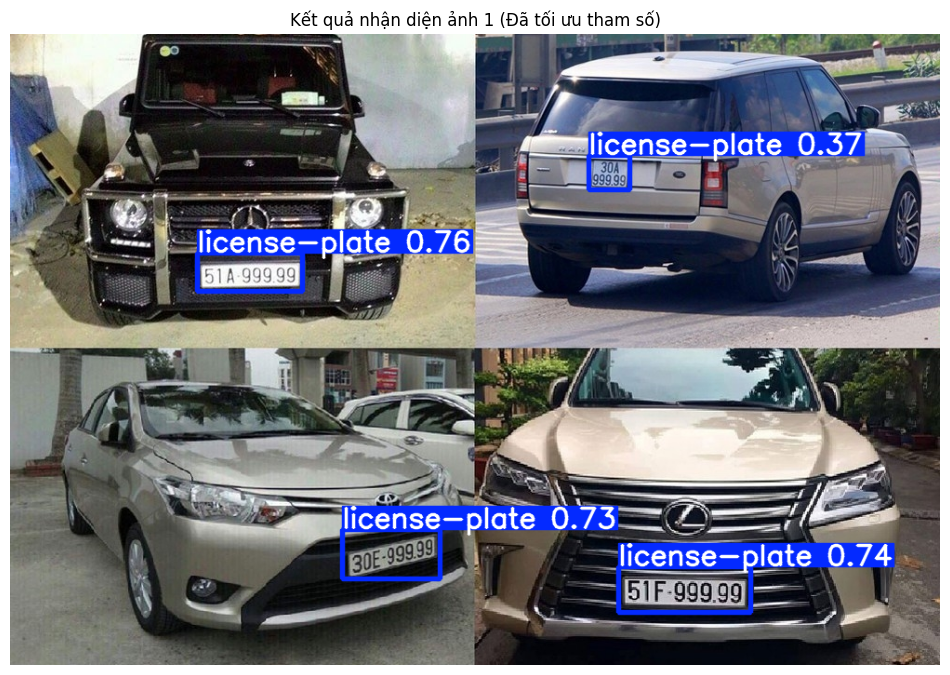


[XONG] Ảnh kết quả đã được tự động lưu vào thư mục 'runs/detect/predict' trong Colab!


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image

# 1. Cấu hình đường dẫn trên Google Drive của bạn
MODEL_PATH = "/content/gdrive/MyDrive/ComputerVisionDeveloper/runs/license_plate_train/weights/best.pt"
IMAGE_TEST_PATH = "/content/bien_so.jpg"

if not os.path.exists(MODEL_PATH):
    print("[LỖI] Không tìm thấy file model! Hãy kiểm tra lại đường dẫn.")
else:
    print("-> Đang khởi tạo model YOLOv8...")
    model = YOLO(MODEL_PATH)

    print(f"-> Đang chạy nhận diện biển số cho: {IMAGE_TEST_PATH}")

    # ==================== ĐOẠN THAY ĐỔI QUAN TRỌNG ====================
    # conf=0.15: Hạ ngưỡng tự tin xuống 15% để model không bỏ sót các biển số bị mờ/khuất/nhỏ
    # iou=0.45: Ngưỡng loại bỏ các khung trùng lặp
    # augment=True: Kích hoạt TTA (Test-Time Augmentation) - tự động lật, phóng to,
    #              thay đổi độ sáng của ảnh lúc test để tìm kiếm đối tượng tốt hơn.
    results = model(IMAGE_TEST_PATH, conf=0.15, iou=0.45, augment=True, save=True)
    # =================================================================

    print("\n=== THÔNG TIN CHI TIẾT DỰ ĐOÁN ===")
    for idx, result in enumerate(results):
        boxes = result.boxes
        print(f"\n[Ảnh {idx + 1}]: Phát hiện {len(boxes)} biển số xe.")

        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            confidence = box.conf[0].item()
            class_id = int(box.cls[0].item())
            class_name = model.names[class_id]

            print(f" - Nhãn: {class_name} | Độ tin cậy: {confidence*100:.2f}%")
            print(f"   Tọa độ Box: [{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]")

        if len(results) <= 5:
            annotated_frame = result.plot()
            annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(12, 10)) # Tăng kích thước hình hiển thị
            plt.imshow(annotated_frame_rgb)
            plt.axis('off')
            plt.title(f"Kết quả nhận diện ảnh {idx + 1} (Đã tối ưu tham số)")
            plt.show()

    print("\n[XONG] Ảnh kết quả đã được tự động lưu vào thư mục 'runs/detect/predict' trong Colab!")

In [ ]:
!ls "/content/gdrive/MyDrive/ComputerVisionDeveloper/runs/license_plate_train"

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg      val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg      val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch52960.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch52961.jpg  weights
labels.jpg			 train_batch52962.jpg


In [ ]:
!pip install scikit-learn matplotlib seaborn

In [ ]:
from ultralytics import YOLO

# 1. Đường dẫn tới file trọng số tốt nhất (best.pt) trong thư mục lưu của bạn
model_path = '/content/gdrive/MyDrive/ComputerVisionDeveloper/runs/license_plate_train/weights/best.pt'

# 2. Load model đã train
model = YOLO(model_path)

# 3. Tiến hành đánh giá trên tập validation (được cấu hình trong file data.yaml)
# Bạn có thể đổi split='test' nếu muốn đánh giá trên tập test riêng biệt
metrics = model.val(split='val')

# 4. In ra các chỉ số chính
print("\n=== KẾT QUẢ ĐÁNH GIÁ ===")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1142.0±235.1 MB/s, size: 34.5 KB)
val: Scanning /content/dataset_lp/valid/labels.cache... 2046 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2046/2046 536.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 3.5it/s 36.2s
                   all       2046       2132      0.982       0.97      0.986      0.693
Speed: 1.7ms preprocess, 10.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val

=== KẾT QUẢ ĐÁNH GIÁ ===
mAP50: 0.9864
mAP50-95: 0.6926
Precision: 0.9820
Recall: 0.9704


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image

# 1. Cấu hình đường dẫn trên Google Drive của bạn
MODEL_PATH = "/content/gdrive/MyDrive/ComputerVisionDeveloper/runs/license_plate_train/weights/best.pt"

IMAGE_TEST_PATH = "/content/bien_so.jpg"

# 2. Kiểm tra xem file model có tồn tại không
if not os.path.exists(MODEL_PATH):
    print("[LỖI] Không tìm thấy file model! Hãy kiểm tra lại đường dẫn.")
else:
    print("-> Đang khởi tạo model YOLOv8...")
    model = YOLO(MODEL_PATH)

    # 3. Chạy dự đoán (Inference)
    # conf=0.25: Chỉ lấy các bounding box có độ tự tin trên 25%
    # save=True: Tự động lưu ảnh đã vẽ khung nhận diện
    print(f"-> Đang chạy nhận diện biển số cho: {IMAGE_TEST_PATH}")
    results = model(IMAGE_TEST_PATH, conf=0.25, save=True)

    print("\n=== THÔNG TIN CHI TIẾT DỰ ĐOÁN ===")
    for idx, result in enumerate(results):
        boxes = result.boxes
        print(f"\n[Ảnh {idx + 1}]: Phát hiện {len(boxes)} biển số xe.")

        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            confidence = box.conf[0].item()
            class_id = int(box.cls[0].item())
            class_name = model.names[class_id]

            print(f" - Nhãn: {class_name} | Độ tin cậy: {confidence*100:.2f}%")
            print(f"   Tọa độ Box: [{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]")

        # 4. Hiển thị ảnh kết quả trực quan ngay trên màn hình Colab
        # (Chỉ hiển thị nếu bạn test 1 ảnh hoặc số lượng ít để tránh tràn bộ nhớ)
        if len(results) <= 5:
            annotated_frame = result.plot() # Lấy ảnh đã vẽ sẵn box (dạng BGR)
            annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB) # Chuyển sang RGB để hiển thị đúng màu

            plt.figure(figsize=(10, 10))
            plt.imshow(annotated_frame_rgb)
            plt.axis('off')
            plt.title(f"Kết quả nhận diện ảnh {idx + 1}")
            plt.show()

    print("\n[XONG] Ảnh kết quả đã được tự động lưu vào thư mục 'runs/detect/predict' trong Colab!")

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image

# 1. Cấu hình đường dẫn trên Google Drive của bạn
MODEL_PATH = "/content/gdrive/MyDrive/ComputerVisionDeveloper/runs/license_plate_train/weights/best.pt"
IMAGE_TEST_PATH = "/content/bien_so.jpg"

if not os.path.exists(MODEL_PATH):
    print("[LỖI] Không tìm thấy file model! Hãy kiểm tra lại đường dẫn.")
else:
    print("-> Đang khởi tạo model YOLOv8...")
    model = YOLO(MODEL_PATH)

    print(f"-> Đang chạy nhận diện biển số cho: {IMAGE_TEST_PATH}")

    # ==================== ĐOẠN THAY ĐỔI QUAN TRỌNG ====================
    # conf=0.15: Hạ ngưỡng tự tin xuống 15% để model không bỏ sót các biển số bị mờ/khuất/nhỏ
    # iou=0.45: Ngưỡng loại bỏ các khung trùng lặp
    # augment=True: Kích hoạt TTA (Test-Time Augmentation) - tự động lật, phóng to,
    #              thay đổi độ sáng của ảnh lúc test để tìm kiếm đối tượng tốt hơn.
    results = model(IMAGE_TEST_PATH, conf=0.15, iou=0.45, augment=True, save=True)
    # =================================================================

    print("\n=== THÔNG TIN CHI TIẾT DỰ ĐOÁN ===")
    for idx, result in enumerate(results):
        boxes = result.boxes
        print(f"\n[Ảnh {idx + 1}]: Phát hiện {len(boxes)} biển số xe.")

        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            confidence = box.conf[0].item()
            class_id = int(box.cls[0].item())
            class_name = model.names[class_id]

            print(f" - Nhãn: {class_name} | Độ tin cậy: {confidence*100:.2f}%")
            print(f"   Tọa độ Box: [{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]")

        if len(results) <= 5:
            annotated_frame = result.plot()
            annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(12, 10)) # Tăng kích thước hình hiển thị
            plt.imshow(annotated_frame_rgb)
            plt.axis('off')
            plt.title(f"Kết quả nhận diện ảnh {idx + 1} (Đã tối ưu tham số)")
            plt.show()

    print("\n[XONG] Ảnh kết quả đã được tự động lưu vào thư mục 'runs/detect/predict' trong Colab!")

In [ ]:
import os
import cv2
from ultralytics import YOLO

# 1. Cấu hình đường dẫn trên Google Colab / Drive của bạn
MODEL_PATH = "/content/gdrive/MyDrive/ComputerVisionDeveloper/runs/license_plate_train/weights/best.pt"

# Thay bằng đường dẫn tới file video test của bạn (có thể để ở /content/ hoặc trong Drive)
VIDEO_TEST_PATH = "/content/test_video.mp4"

# Thư mục lưu video kết quả đầu ra
OUTPUT_DIR = "/content/runs/detect/video_result"

if not os.path.exists(MODEL_PATH):
    print("[LỖI] Không tìm thấy file model! Hãy kiểm tra lại đường dẫn.")
elif not os.path.exists(VIDEO_TEST_PATH):
    print(f"[LỖI] Không tìm thấy file video test tại: {VIDEO_TEST_PATH}")
else:
    print("-> Đang khởi tạo model YOLO...")
    model = YOLO(MODEL_PATH)

    print(f"-> Đang tiến hành quét và nhận diện video: {VIDEO_TEST_PATH}")
    print("-> Quá trình này có thể mất vài phút tùy thuộc vào độ dài của video...")

    # 2. Chạy dự đoán trên Video
    # conf=0.15 và augment=True để tối ưu khả năng bắt biển số như đã sửa ở ảnh trước
    # save=True: Bắt buộc để YOLO lưu lại file video đã vẽ box
    results = model(
        source=VIDEO_TEST_PATH,
        conf=0.15,
        iou=0.45,
        augment=True,
        save=True,
        project=OUTPUT_DIR,
        name="predict_video"
    )

    print("\n✓ Xử lý video xong!")
    # Đường dẫn file video mà YOLO vừa xuất ra (thường mặc định là file .avi hoặc .mp4 tùy phiên bản)
    saved_video_path = os.path.join(OUTPUT_DIR, "predict_video", os.path.basename(VIDEO_TEST_PATH))
    print(f"Video kết quả gốc được lưu tại: {saved_video_path}")

In [ ]:
from google.colab import files

# Đường dẫn tới file trọng số tốt nhất của bạn trên Drive
model_path = "/content/gdrive/MyDrive/ComputerVisionDeveloper/runs/license_plate_train/weights/best.pt"

# Lệnh tải file về máy tính cá nhân
files.download(model_path)